#### KMeans聚类

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

DATA_DIR = '../数据'
df = pd.read_csv(os.path.join(DATA_DIR, 'processed_jobs.csv'))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

cluster_cols = ['月薪均值', '经验年限', '学历编码', '规模编码']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_cols])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

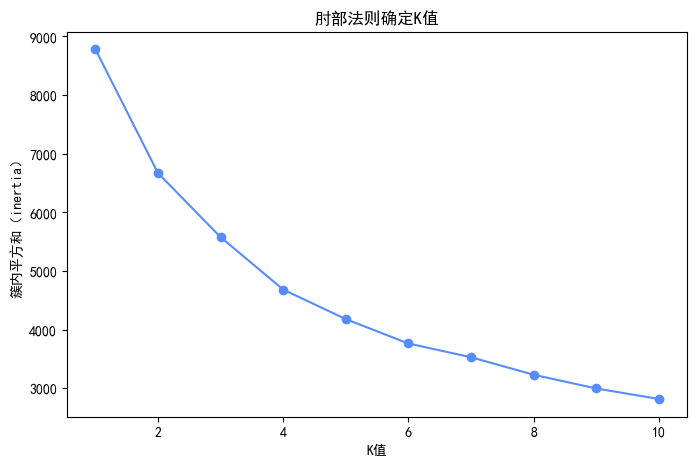

In [2]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('K值')
plt.ylabel('簇内平方和（inertia）')
plt.title('肘部法则确定K值')
plt.show()

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)
df['cluster'].value_counts()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


cluster
0    780
1    629
2    422
3    365
Name: count, dtype: int64

#### 聚类结果可视化

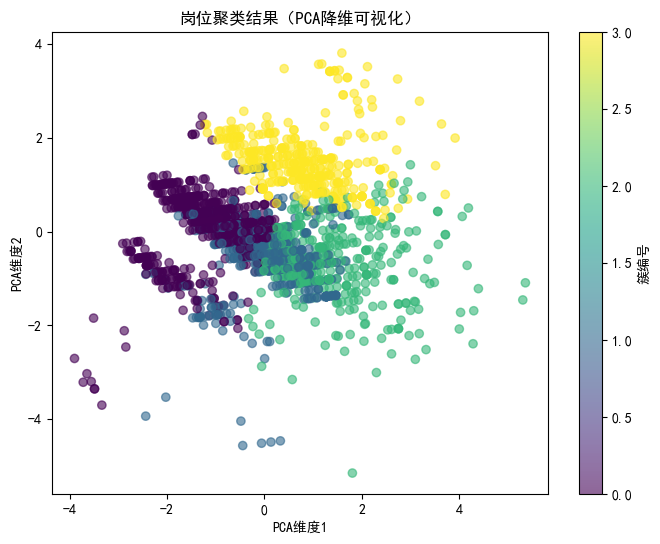

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA维度1')
plt.ylabel('PCA维度2')
plt.title('岗位聚类结果（PCA降维可视化）')
plt.colorbar(label='簇编号')
plt.show()

#### 各簇特征分析

In [6]:
df.groupby('cluster')[cluster_cols].mean().round(2)

,月薪均值,经验年限,学历编码,规模编码
cluster,,,,
0,1.27,2.00,2.82,2.03
1,1.59,2.52,2.95,5.62
2,2.68,5.08,3.10,3.55
3,2.42,1.82,4.02,3.39


In [7]:
cluster_names = {
    0: '初级岗',
    1: '大厂基础岗',
    2: '资深/管理岗',
    3: '高学历起薪岗'
}
df['岗位画像'] = df['cluster'].map(cluster_names)
df['岗位画像'].value_counts()

岗位画像
初级岗       780
大厂基础岗     629
资深/管理岗    422
高学历起薪岗    365
Name: count, dtype: int64

In [8]:
df.to_csv(os.path.join(DATA_DIR, 'clustered_jobs.csv'), index=False, encoding='utf-8-sig')